# **Convolución para MNIST-1D**

Este cuaderno explora una red convolucional 1D para MNIST-1D.

Ejecuta las celdas en orden. En varios lugares verás la palabra "TAREA": sigue esas instrucciones, anticipa qué ocurrirá o escribe el código necesario para completar las funciones.


In [1]:
# Ejecuta esta celda una vez si necesitas instalar el repositorio MNIST-1D
!pip install git+https://github.com/greydanus/mnist1d

  Cloning https://github.com/greydanus/mnist1d to C:\Users\User\AppData\Local\Temp\pip-req-build-4wuplzsr
  Resolved https://github.com/greydanus/mnist1d to commit 7878d96082abd200c546a07a4101fa90b30fdf7e
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
    --------------------------------------- 0.8/36.6 MB 6.2 MB/s eta 0:00:06
   --- ------------------------------------ 2.9/36.6 MB 8.5 MB/s eta 0:00:04
   ----- ---------------------------------- 4.7/36.6 MB 8.6 MB/s eta 0:00:04
   ------- -------------------------------- 6.6/36.6 MB 8.7 MB/s eta 0:00:04
   --------- ------------------------------ 8.7/36.6 MB 8.9 MB/s eta 0:00:04
   -------

  Running command git clone --filter=blob:none --quiet https://github.com/greydanus/mnist1d 'C:\Users\User\AppData\Local\Temp\pip-req-build-4wuplzsr'


In [3]:
import numpy as np
import os
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
import mnist1d
import random

In [4]:
args = mnist1d.data.get_dataset_args()
data = mnist1d.data.get_dataset(args, path='./mnist1d_data.pkl', download=False, regenerate=False)

# Las entradas y salidas de entrenamiento y prueba están en
# data['x'], data['y'], data['x_test'] y data['y_test']
print("Samples in training set: {}".format(len(data['y'])))
print("Samples in test set: {}".format(len(data['y_test'])))
print("Length of each sample: {}".format(data['x'].shape[-1]))

Did or could not load data from ./mnist1d_data.pkl. Rebuilding dataset...
Samples in training set: 4000
Samples in test set: 1000
Length of each sample: 40


In [5]:
# Carga los datos
train_data_x = data['x'].transpose()
train_data_y = data['y']
val_data_x = data['x_test'].transpose()
val_data_y = data['y_test']
# Muestra los tamaños
print("Training data: %d samples (columns), each with %d dimensions (rows)"%((train_data_x.shape[1],train_data_x.shape[0])))
print("Validation data: %d samples (columns), each with %d dimensions (rows)"%((val_data_x.shape[1],val_data_x.shape[0])))

Training data: 4000 samples (columns), each with 40 dimensions (rows)
Validation data: 1000 samples (columns), each with 40 dimensions (rows)


Define la red

In [ ]:
# Estos datos tienen 40 dimensiones de entrada y 10 dimensiones de salida
# Las entradas corresponden a los 40 desplazamientos de la plantilla MNIST-1D.
D_i = 40
# Las salidas corresponden a los 10 dígitos
D_o = 10


# TAREA: crea un modelo con las siguientes capas
# 1. Capa convolucional (entrada: longitud 40 y 1 canal; kernel 3; paso 2; padding="valid"; 15 canales de salida)
# 2. ReLU
# 3. Capa convolucional (entrada: longitud 19 y 15 canales; kernel 3; paso 2; padding="valid"; 15 canales de salida)
# 4. ReLU
# 5. Capa convolucional (entrada: longitud 9 y 15 canales; kernel 3; paso 2; padding="valid"; 15 canales de salida)
# 6. ReLU
# 7. Aplanamiento (convierte 4x15) a longitud 60
# 8. Capa lineal (tamaño de entrada = 60, tamaño de salida = 10)
# Documentación útil:
# https://pytorch.org/docs/1.13/generated/torch.nn.Conv1d.html?highlight=conv1d#torch.nn.Conv1d
# https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html
# https://pytorch.org/docs/1.13/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear

# TEN EN CUENTA QUE LAS CAPAS CONVOLUCIONALES NECESITAN RECIBIR EL NÚMERO DE CANALES DE ENTRADA COMO PARÁMETRO
# Y NO EL TAMAÑO DE LA ENTRADA.

# Reemplaza la siguiente función:
model = nn.Sequential(
nn.Flatten(),
nn.Linear(40, 100),
nn.ReLU(),
nn.Linear(100, 100),
nn.ReLU(),
nn.Linear(100, 10))





In [6]:
# Datos
D_i = 40
D_o = 40

model = nn.Sequential(
    
    # 1. Capa convolucional (entrada: longitud 40 y 1 canal; kernel 3; paso 2; padding="valid"; 15 canales de salida)
    nn.Conv1d(
        in_channels=1,
        out_channels=15,
        kernel_size=3,
        stride=2,
        padding=0
    ),
    nn.ReLU(), # 2. ReLU

    # 3. Capa convolucional (entrada: longitud 19 y 15 canales; kernel 3; paso 2; padding="valid"; 15 canales de salida)
    nn.Conv1d(
        in_channels=15,
        out_channels=15,
        kernel_size=3,
        stride=2,
        padding=0
    ),
    nn.ReLU(), # 4. ReLU

    # 5. Capa convolucional (entrada: longitud 9 y 15 canales; kernel 3; paso 2; padding="valid"; 15 canales de salida)
    nn.Conv1d(
        in_channels=15,
        out_channels=15,
        kernel_size=3,
        stride=2,
        padding=0
    ),
    nn.ReLU(), # 6. ReLU

    # 7. Aplanamiento (convierte 4x15) a longitud 60
    nn.Flatten(),

    # 8. Capa lineal (tamaño de entrada = 60, tamaño de salida = 10)
    nn.Linear(60, 10)
)



In [7]:
# Inicialización de pesos de He
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

Epoch     0, training loss 1.869261, training error 73.80, validation loss 1.897911, validation error 76.50
Epoch     1, training loss 1.547971, training error 61.45, validation loss 1.576813, validation error 63.40
Epoch     2, training loss 1.399790, training error 56.25, validation loss 1.418988, validation error 57.60
Epoch     3, training loss 1.270585, training error 51.60, validation loss 1.294618, validation error 55.10
Epoch     4, training loss 1.191483, training error 48.45, validation loss 1.212462, validation error 51.00
Epoch     5, training loss 1.073570, training error 42.85, validation loss 1.115025, validation error 46.70
Epoch     6, training loss 1.024148, training error 42.45, validation loss 1.090067, validation error 46.20
Epoch     7, training loss 0.971919, training error 40.12, validation loss 1.018079, validation error 41.60
Epoch     8, training loss 0.902566, training error 36.33, validation loss 0.947730, validation error 39.00
Epoch     9, training loss 0

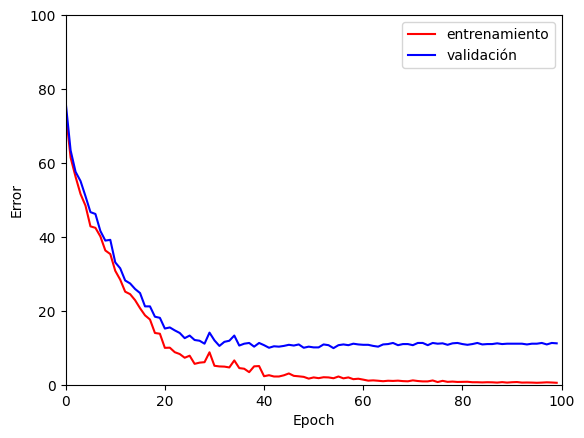

In [8]:
# Elige la función de pérdida de entropía cruzada
loss_function = nn.CrossEntropyLoss()
# Construye el optimizador SGD e inicializa la tasa de aprendizaje y el momentum
optimizer = torch.optim.SGD(model.parameters(), lr = 0.05, momentum=0.9)
# Objeto que reduce la tasa de aprendizaje a la mitad cada 20 épocas
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
# Crea los tensores de datos y guárdalos en un DataLoader
x_train = torch.tensor(train_data_x.transpose().astype('float32'))
y_train = torch.tensor(train_data_y.astype('long')).long()
x_val= torch.tensor(val_data_x.transpose().astype('float32'))
y_val = torch.tensor(val_data_y.astype('long')).long()

# Carga los datos en una clase que crea los lotes
data_loader = DataLoader(TensorDataset(x_train,y_train), batch_size=100, shuffle=True, worker_init_fn=np.random.seed(1))

# Inicializa los pesos del modelo
model.apply(weights_init)

# Recorre el conjunto de datos n_epoch veces
n_epoch = 100
# Guarda la pérdida y el porcentaje de error en cada época
losses_train = np.zeros((n_epoch))
errors_train = np.zeros((n_epoch))
losses_val = np.zeros((n_epoch))
errors_val = np.zeros((n_epoch))

for epoch in range(n_epoch):
  # Recorre los lotes
  for i, data in enumerate(data_loader):
    # Recupera entradas y etiquetas de este lote
    x_batch, y_batch = data
    # Reinicia los gradientes de los parámetros
    optimizer.zero_grad()
    # Paso hacia adelante: calcula la salida del modelo
    pred = model(x_batch[:,None,:])
    # Calcula la pérdida
    loss = loss_function(pred, y_batch)
    # Paso hacia atrás
    loss.backward()
    # Actualización SGD
    optimizer.step()

  # Ejecuta todo el conjunto de datos para obtener estadísticas; normalmente no harías esto
  pred_train = model(x_train[:,None,:])
  pred_val = model(x_val[:,None,:])
  _, predicted_train_class = torch.max(pred_train.data, 1)
  _, predicted_val_class = torch.max(pred_val.data, 1)
  errors_train[epoch] = 100 - 100 * (predicted_train_class == y_train).float().sum() / len(y_train)
  errors_val[epoch]= 100 - 100 * (predicted_val_class == y_val).float().sum() / len(y_val)
  losses_train[epoch] = loss_function(pred_train, y_train).item()
  losses_val[epoch]= loss_function(pred_val, y_val).item()
  print(f'Epoch {epoch:5d}, training loss {losses_train[epoch]:.6f}, training error {errors_train[epoch]:3.2f}, validation loss {losses_val[epoch]:.6f}, validation error {errors_val[epoch]:3.2f}')

  # Indica al programador que evalúe si debe actualizar la tasa de aprendizaje
  scheduler.step()

# Grafica los resultados
fig, ax = plt.subplots()
ax.plot(errors_train,'r-',label='entrenamiento')
ax.plot(errors_val,'b-',label='validación')
ax.set_ylim(0,100); ax.set_xlim(0,n_epoch)
ax.set_xlabel('Epoch'); ax.set_ylabel('Error')
ax.legend()
plt.show()

# A R C H I T E C T U R E


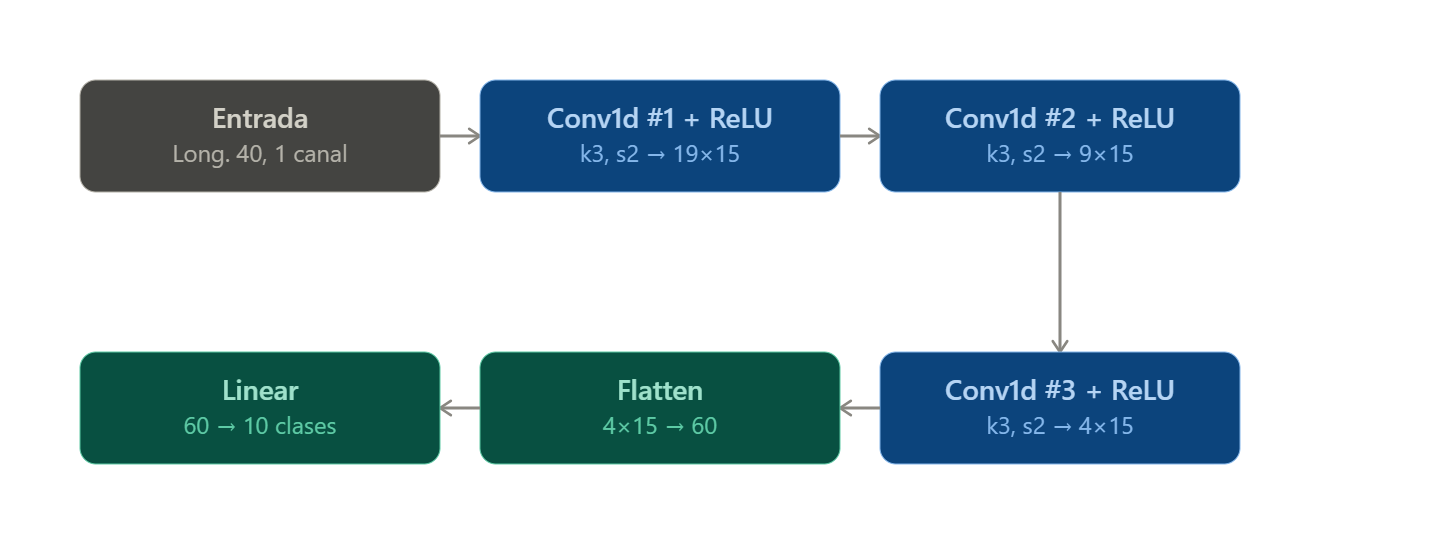


La red convolucional mostró una convergencia adecuada durante el entrenamiento. El error de entrenamiento disminuyó del 72.47% al 1.22%, mientras que el error de validación se redujo del 74.30% al 10.40%.

El menor error de validación se alcanzó alrededor de la época 67 (10.20%), tras lo cual las métricas se estabilizaron sin mejoras significativas adicionales.

Estos resultados indican que el modelo logró aprender correctamente las características de las señales MNIST-1D. La diferencia entre el error de entrenamiento (1.22%) y el de validación (10.40%) refleja un ligero sobreajuste, esperable dado el tamaño reducido del conjunto de datos, pero no lo suficientemente marcado como para comprometer la capacidad de generalización del modelo.